In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("/content/movies.csv")
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [6]:
df.shape

(9999, 9)

In [7]:
df_x = df.copy()
df_x.isna().sum()

,0
MOVIES,0
YEAR,644
GENRE,80
RATING,1820
ONE-LINE,0
STARS,0
VOTES,1820
RunTime,2958
Gross,9539


In [8]:
df_x = df_x.dropna()
df_x.shape

(460, 9)

In [10]:
chars_to_remove = ["(",")","-","I","II","III"," ","("]
for i in chars_to_remove:
  df_x["YEAR"] = df_x["YEAR"].apply(lambda x:x.strip(i))
df_x["YEAR"] =df_x["YEAR"].astype(int)

In [11]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 460 entries, 77 to 6292
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    460 non-null    object 
 1   YEAR      460 non-null    int64  
 2   GENRE     460 non-null    object 
 3   RATING    460 non-null    float64
 4   ONE-LINE  460 non-null    object 
 5   STARS     460 non-null    object 
 6   VOTES     460 non-null    object 
 7   RunTime   460 non-null    float64
 8   Gross     460 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 35.9+ KB


In [12]:
 df_x["GENRE"] = df_x["GENRE"].apply(lambda x:x.strip())
df_x["GENRE"].unique()

array(['Action, Comedy, Crime', 'Action, Adventure, Sci-Fi',
       'Crime, Horror, Thriller', 'Action, Adventure, Drama',
       'Action, Adventure, Horror', 'Adventure, Thriller',
       'Crime, Drama, Thriller', 'Drama, Mystery, Thriller',
       'Action, Adventure, Comedy', 'Comedy, Crime, Drama',
       'Action, Crime, Drama', 'Action, Drama', 'Horror',
       'Adventure, Fantasy', 'Comedy, Romance',
       'Action, Adventure, Thriller', 'Biography, Crime, Drama',
       'Drama, Sci-Fi', 'Crime, Drama', 'Musical, Romance',
       'Action, Adventure, Crime', 'Animation, Adventure, Family',
       'Action, Adventure, Fantasy', 'Adventure, Sci-Fi',
       'Drama, Horror, Mystery', 'Comedy', 'Comedy, Fantasy, Romance',
       'Action, Crime, Thriller', 'Biography, Drama, Sport',
       'Action, Drama, Sci-Fi', 'Animation, Drama, Fantasy',
       'Adventure, Horror, Thriller', 'Action, Comedy, War',
       'Family, Fantasy, Musical', 'Comedy, Drama, Romance',
       'Adventure, Drama, 

In [ ]:
df_x.columns

Index(['MOVIES', 'YEAR', 'GENRE', 'RATING', 'ONE-LINE', 'STARS', 'VOTES',
       'RunTime', 'Gross'],
      dtype='object')

In [24]:
# df_x[~df_x["VOTES"].str.isnumeric()]

# df_x["VOTES"] = df_x["VOTES"].apply(lambda x:x.replace(",",""))
# df_x["VOTES"] = df_x["VOTES"].astype(int)

# df_x["Gross"] = df_x["Gross"].replace(items_to_replace,regex=True)
# df_x["Gross"] = df_x["Gross"].astype(int)
# df_x["Gross"] = df_x["Gross"].apply(lambda x:x.strip('$'))
# df_x["Gross"] = df_x["Gross"].apply(lambda x:x.strip('M'))
# df_x["Gross"] = df_x["Gross"].apply(lambda x:float(x))

df_x.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
77,The Hitman's Bodyguard,2017,"Action, Comedy, Crime",6.9,"\nThe world's top bodyguard gets a new client,...",\n Director:\nPatrick Hughes\n| \n Stars...,205979,118.0,75.47
85,Jurassic Park,1993,"Action, Adventure, Sci-Fi",8.1,\nA pragmatic paleontologist visiting an almos...,\n Director:\nSteven Spielberg\n| \n Sta...,897444,127.0,402.45
95,Don't Breathe,2016,"Crime, Horror, Thriller",7.1,"\nHoping to walk away with a massive fortune, ...",\n Director:\nFede Alvarez\n| \n Stars:\...,237601,88.0,89.22
111,The Lord of the Rings: The Fellowship of the Ring,2001,"Action, Adventure, Drama",8.8,\nA meek Hobbit from the Shire and eight compa...,\n Director:\nPeter Jackson\n| \n Stars:...,1713028,178.0,315.54
125,Escape Room,2019,"Action, Adventure, Horror",6.4,\nSix strangers find themselves in a maze of d...,\n Director:\nAdam Robitel\n| \n Stars:\...,99351,99.0,57.01


In [25]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 460 entries, 77 to 6292
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    460 non-null    object 
 1   YEAR      460 non-null    int64  
 2   GENRE     460 non-null    object 
 3   RATING    460 non-null    float64
 4   ONE-LINE  460 non-null    object 
 5   STARS     460 non-null    object 
 6   VOTES     460 non-null    int64  
 7   RunTime   460 non-null    float64
 8   Gross     460 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 35.9+ KB


In [57]:
# df_x.drop("GENRE",axis=1,inplace=True)
# df_x.drop("STARS",axis=1,inplace=True)
df_x.drop("ONE-LINE",axis=1,inplace=True)


df_x.head()

,MOVIES,YEAR,RATING,VOTES,RunTime,Gross
77,The Hitman's Bodyguard,2017,6.9,205979,118.0,75.47
85,Jurassic Park,1993,8.1,897444,127.0,402.45
95,Don't Breathe,2016,7.1,237601,88.0,89.22
111,The Lord of the Rings: The Fellowship of the Ring,2001,8.8,1713028,178.0,315.54
125,Escape Room,2019,6.4,99351,99.0,57.01


In [58]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 460 entries, 77 to 6292
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MOVIES   460 non-null    object 
 1   YEAR     460 non-null    int64  
 2   RATING   460 non-null    float64
 3   VOTES    460 non-null    int64  
 4   RunTime  460 non-null    float64
 5   Gross    460 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 41.3+ KB


In [60]:
df_x.to_csv("movies_cleaned.csv",index=False)

In [61]:
DF = pd.read_csv("/content/movies_cleaned.csv")
DF.head()

,MOVIES,YEAR,RATING,VOTES,RunTime,Gross
0,The Hitman's Bodyguard,2017,6.9,205979,118.0,75.47
1,Jurassic Park,1993,8.1,897444,127.0,402.45
2,Don't Breathe,2016,7.1,237601,88.0,89.22
3,The Lord of the Rings: The Fellowship of the Ring,2001,8.8,1713028,178.0,315.54
4,Escape Room,2019,6.4,99351,99.0,57.01


### cleaning over
# its time for EDA










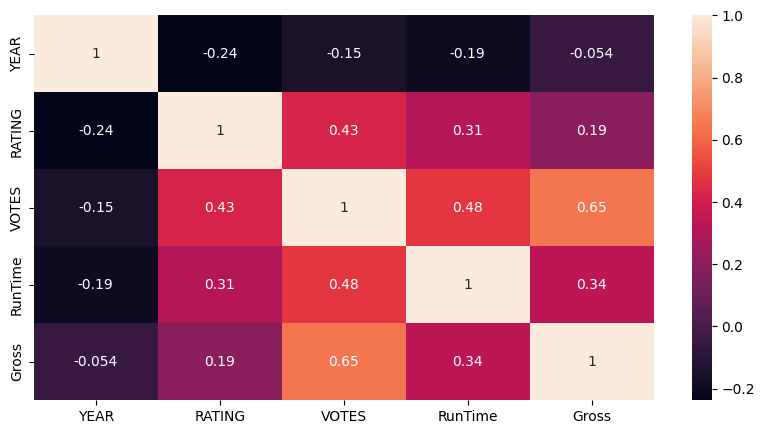

In [69]:
plt.figure(figsize=(10, 5))
sns.heatmap(DF.corr(numeric_only=True),annot=True)
plt.show()

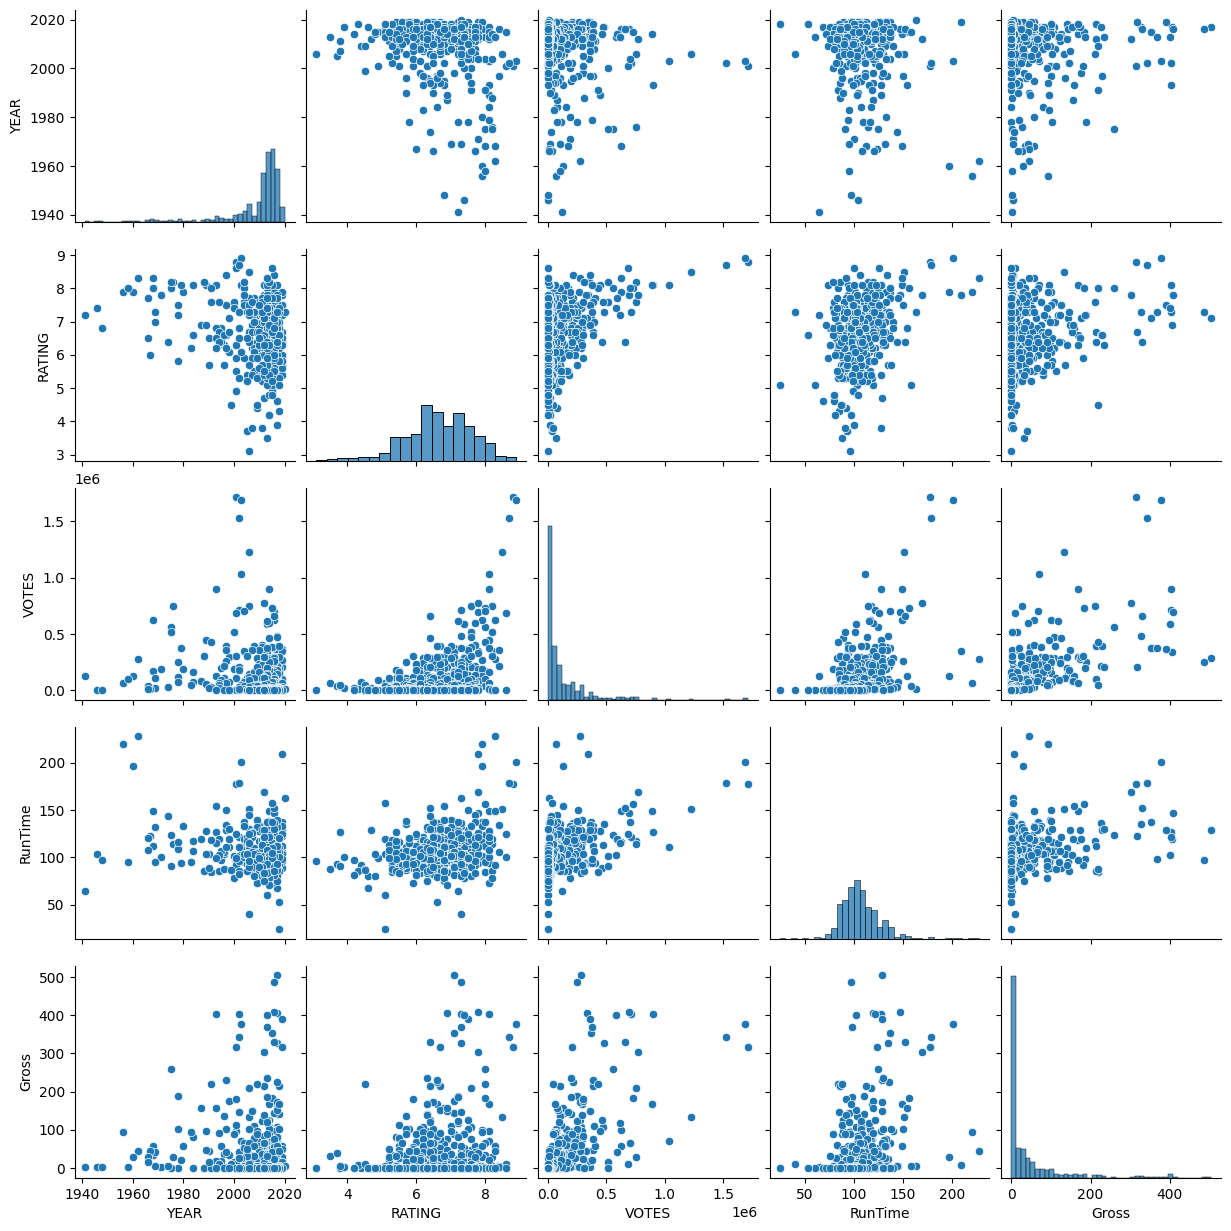

In [70]:
sns.pairplot(DF)

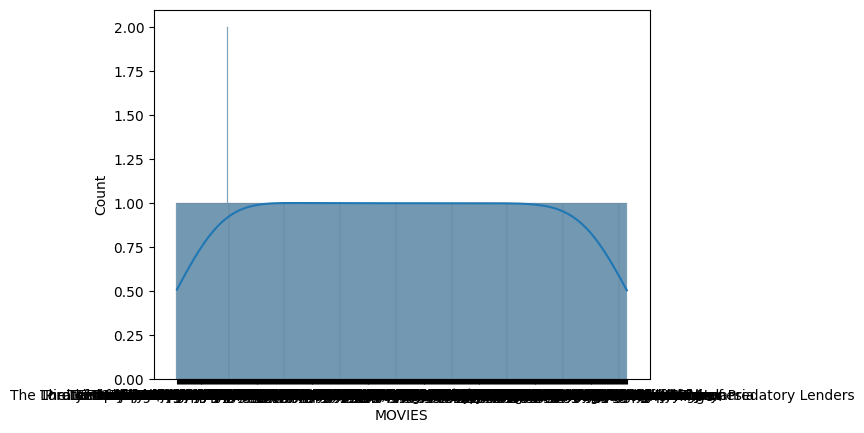

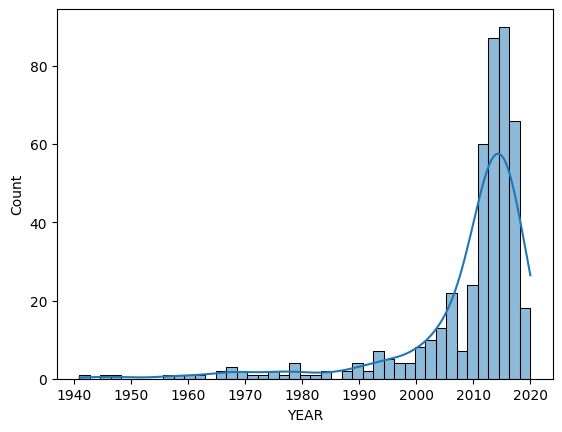

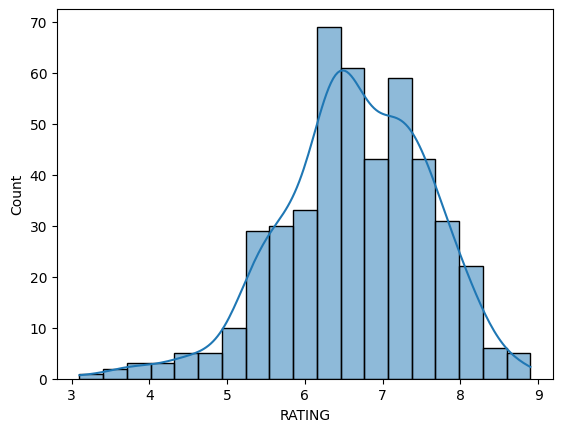

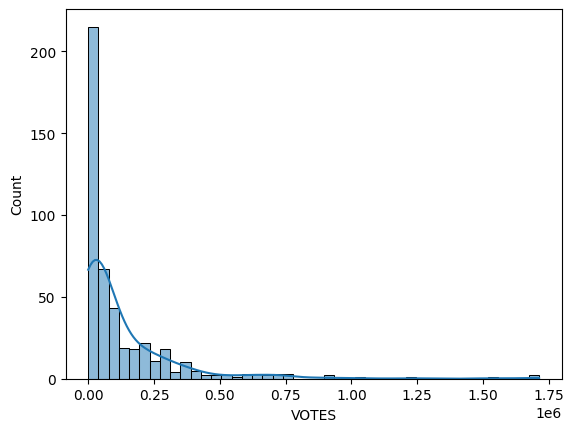

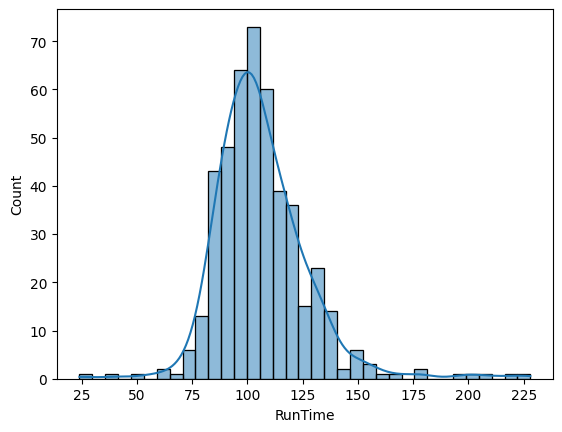

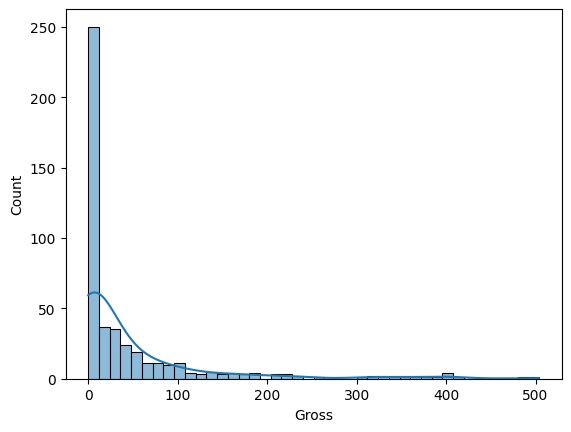

In [77]:
# histogram
for cols in DF.columns:
  sns.histplot(DF[cols],kde=True)
  plt.show()

<Axes: xlabel='RunTime', ylabel='Gross'>

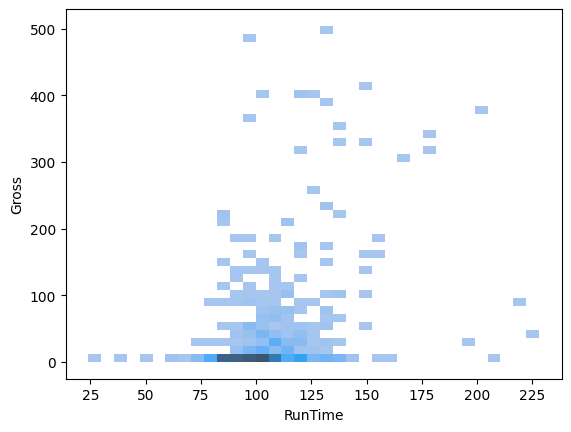

In [81]:
# analysis of runtime with gross
sns.color_palette("hls", 8)

sns.histplot(x="RunTime",y="Gross",data=DF)